Considering more realistic and useful embedding sizes and encode the input tokens into a 256-dimensional vector representation.

This is smaller than the original GOT-3 model used (in GPT-3, the embedding size is 12,288 dimensions) but still reasonable for experimentation.

furthermore, we assume that the token IDs were created by the BPE tokenizer that we implemented earlier, which has a vocabulary size of 50,257:

In [2]:
import torch
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

Using the token_embedding_layer above, if we sample data from the data loader, we embed each token in each batch into a 256-dimensional vector. If we have a batch size of 8 with four tokens each, the result will be an 8 x 4 x 256 tensor.

Lets instantiate the data loader (Data sampling with a sliding window), first:

In [12]:
import re
with open(r'The_Verdict.txt', 'r', encoding="utf-8", errors='ignore') as f:
    raw_text = f.read()

In [13]:
from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset): #Note that the Dataset cannot be a bunch of tokens, but it should be an Input/Oupput pairs
  def __init__(self, txt, tokenizer, max_length, stride): #txt= text file, tokenizer= BPE, max_length= context_size, stride= next set of input chunks ie[the, city, stood, the]
    self.input_ids = []
    self.target_ids = []

    # Tokenize the entire text
    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

    #Use a sliding wwindow to chunk the book into overlapping sequences of max_length
    for i in range(0, len(token_ids)-max_length, stride):
      input_chunk = token_ids[i:i+max_length]
      target_chunk = token_ids[i+1:i+max_length+1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

#
  def __len__(self):
    return len(self.input_ids)

#Below idx is index. here we tell that if the idx is 50 then the input will be the 50th row of the input tensor and the target will be the 50th row of the output tensor
#The __get_item__() is finally what the data loader will be using.
  def __getitem__(self,idx):
    return self.input_ids[idx], self.target_ids[idx]

In [14]:
import tiktoken
#The below function will implement the :batch processing" or "parallel processing" that we need.
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
  #txt=textfiles, batch_size= no of CPU processes to be run, max_lenght= context_length(default-256), stride= when we create a I/O batch how much we want to skip before the next batch is stride, num_workers= No of CPU threads that we can run simultaneously

  #Initialize the tokenizer
  tokenizer = tiktoken.get_encoding("gpt2") #tiktoken- is the BPE used by gpt

  #Create dataset
  dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

  #Create dataloader
  dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                          drop_last = drop_last, num_workers=num_workers)
  return dataloader

In [15]:
max_length = 4
dataloader = create_dataloader_v1(raw_text, batch_size=8,max_length=max_length, stride=max_length, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)

In [16]:
print("Token IDs:\n", inputs)
print("\nInputs shape:\n",inputs.shape)

Token IDs:
 tensor([[  198,    40,   367,  2885],
        [ 1464,  1807,  3619,   402],
        [  271, 10899,  2138,   257],
        [ 7026, 15632,    12,  2016],
        [  257,   922,  5891,  1576],
        [  438,   568,   340,   373],
        [  645,  1049,  5975,   284],
        [  502,   284,  3285,   326]])

Inputs shape:
 torch.Size([8, 4])


From the above matrix for each token-ID ie, for example lets take 40, for this we need to create a vector dimension of 256 or a 256 dimensional vector representation.

As we can see, the token ID tensor is 8x4 dimensional, meaning that the data batch consists of 8 text samples with 4 tokens each.

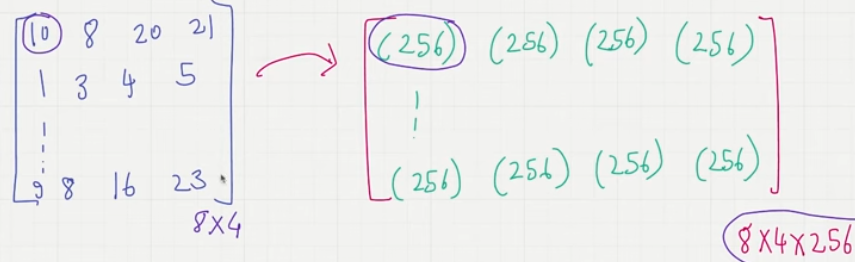

In [17]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


Based on the 8x4x256 dimensional tensor output, each token ID is now embedded as a 256-dimensional vector.

For a GPT model's absolute embedding approach, we just need to create another embedding layer that hass the same dimension

In [18]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

In [19]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length))
print(pos_embeddings.shape)

torch.Size([4, 256])


As shown in the preceding code example, the input to the pos_embeddings is usually a placeholder vector torch.arange with a sequence of numbers 0,1,...., up to the maximum input length -1.

The context_length is a variable that represents the supported input size of the LLM.

Here, we choose it similar to the maximum length of the input text.

In practice, inut text can be longer than the supported context length, in which case we have to truncate the text.

As we can see the positional embedding tensor consists of four 256-dimensional vectors. We can now add these directly to the token embeddings, where PyTorch will add the 4x256- dimensional pos_emnbeddings tensor to each 4x256-dimensional token embedding tensor in each of the 8 bathces: